<a href="https://colab.research.google.com/github/k-gyo/MLDL/blob/main/%ED%98%BC%EC%9E%90%20%EA%B3%B5%EB%B6%80%ED%95%98%EB%8A%94%20%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%20%2B%20%EB%94%A5%EB%9F%AC%EB%8B%9D/Chapter09_%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%A5%BC_%EC%9C%84%ED%95%9C_%EC%9D%B8%EA%B3%B5_%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMDB 리뷰 데이터셋**

In [6]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 600.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.7 MB/s eta 0:00:00


In [7]:
from tensorflow.keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


- IMDM 리뷰 텍스트는 길이가 제각각
  > 따라서 리뷰마다 별도의 파이썬 리스트에 담겨 있음


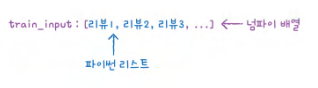

In [9]:
print(len(train_input[0]))

218


In [10]:
print(len(train_input[1]))

189


In [11]:
print(train_input[0])
# 어휘 사전에는 500개의 단어만 들어가 있으므로 어휘 사전에 없는 단어로 모두 2로 표시됨

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [12]:
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [13]:
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [14]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

In [15]:
print(np.mean(lengths), np.median(lengths))

239.00925 178.0


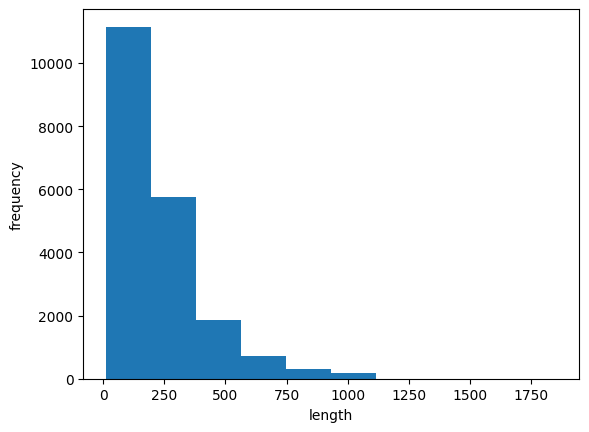

In [16]:
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences (train_input, maxlen=100)
# maxlen 길이에 맞춰 긴 경우는 잘라내고 짧은 경우는 0으로 패딩

In [18]:
print(train_seq.shape)

(20000, 100)


In [19]:
print(train_seq[0])

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [20]:
print(train_input[0][-10:])
# 뒷부분이 같은 것으로 보아 샘플의 앞부분이 잘렸다는 것을 알 수 있음
# pad_sequences() 함수는 기본으로 maxlen보다 긴 시퀀스의 앞부분을 자름
# 일반적으로 시퀀스의 뒷부분의 정보가 더 유용하리라 판단하기 때문

[6, 2, 46, 7, 14, 20, 10, 10, 470, 158]


In [21]:
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


In [22]:
val_seq = pad_sequences(val_input, maxlen=100)

# **순환 신경망 만들기**

In [23]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.SimpleRNN(8, input_shape=(100, 500)))
# 첫 번째 차원이 100인 것은 앞에서 샘플의 길이를 100으로 지정했기 때문
# 두 번째 차원이 500인 이유는 0(패딩 토큰)에서 499까지 원-핫 인코딩으로 표현하려는 배열의 길이
model.add(keras. layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
train_oh = keras.utils.to_categorical(train_seq)

In [25]:
print(train_oh.shape)

(20000, 100, 500)


In [26]:
print (train_oh[0][0][:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [27]:
print(np.sum(train_oh[0][0]))

1.0


In [28]:
val_oh = keras.utils.to_categorical(val_seq)

In [29]:
model.summary()
# 마지막 타임스템의 은닉 상태만 출력, 출력 크기는 순환층의 뉴런 개수와 동일한 8
# 500차원의 원-핫 인코딩 배열과 뉴런 8개가 완전히 연결되므로 총 500 × 8 = 4,000개의 가중치가 존재
# 순환층의 은닉 상태는 다시 다음 타임스텝에 사용되기 위해 또 다른 가중치와 곱해짐
# 이 은닉 상태도 순환층의 뉴런과 완전이 연결되기 때문에 8(은닉 상태 크기) × 8(뉴런 개수) = 64개의 가중치가 필요
# 마지막으로 뉴런마다 하나의 절편 있으므로 총 4,000 + 64 + 8 = 4,072개의 모델 파라미터가 필요

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

# **순환 신경망 훈련하기**

In [30]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5026 - loss: 0.7014

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5026 - loss: 0.7014 - val_accuracy: 0.4968 - val_loss: 0.6997
Epoch 2/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5189 - loss: 0.6947

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5189 - loss: 0.6947 - val_accuracy: 0.5316 - val_loss: 0.6901
Epoch 3/100
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5663 - loss: 0.6811

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.5665 - loss: 0.6810 - val_accuracy: 0.6094 - val_loss: 0.6702
Epoch 4/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6232 - loss: 0.6616

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6233 - loss: 0.6615 - val_accuracy: 0.6458 - val_loss: 0.6516
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6640 - loss: 0.6430

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8186 - loss: 0.4222 - val_accuracy: 0.7822 - val_loss: 0.4694
Epoch 39/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8152 - loss: 0.4287

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8153 - loss: 0.4286 - val_accuracy: 0.7820 - val_loss: 0.4688
Epoch 40/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8203 - loss: 0.4212

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8203 - loss: 0.4212 - val_accuracy: 0.7828 - val_loss: 0.4692
Epoch 41/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8215 - loss: 0.4173

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8214 - loss: 0.4173 - val_accuracy: 0.7818 - val_loss: 0.4693
Epoch 42/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8207 - loss: 0.4172

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8207 - loss: 0.4172 - val_accuracy: 0.7822 - val_loss: 0.4710


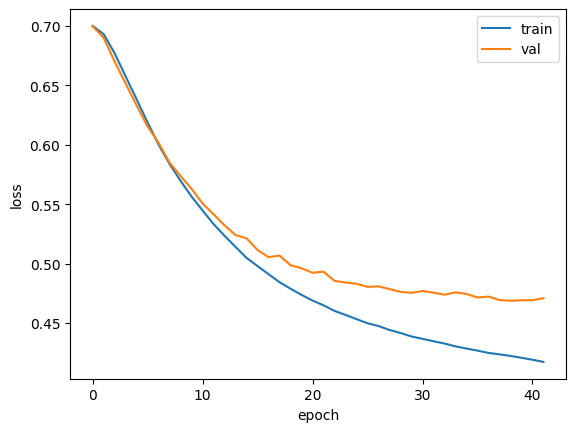

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# **단어 임베딩을 사용하기**

- 장점:
  - 입력으로 정수 데이터를 받음
  > 원 핫 인코딩으로 변경된 train_oh 배열이 아니라 train_seq를 사용할 수 있음

In [51]:
model2 = keras.Sequential()
model2.add(keras.layers.Embedding(500, 16, input_shape=(100,)))
# 첫 번째 매개변수(500)는 어휘 사전의 크기
# 두 번째 매개변수 (16)는 임베딩 벡터의 크기
# 세 번째 input_length 매개변수는 입력 시퀀스의 길이
model2.add(keras.layers.SimpleRNN(8))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

In [52]:
model2.summary()
# 500개의 각 토큰을 크기가 16인 벡터로 변경하기 때문에 총 500 × 16 = 8,000개의 모델 파라미터를 가짐
# SimpleRNN 층은 임베딩 벡터의 크기가 16이므로 8개의 뉴런과 곱하기 위해 필요한 가중치 16 × 8 = 128개
# 또한 은닉 상태에 곱해지는 가중치 8 × 8 = 64개
# 마지막으로 8개의 절편이 있으므로 이 순환층에 있는 전체 모델 파라미터의 개수는 128 + 64 + 8 = 200개

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model2.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4947 - loss: 0.6987

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4947 - loss: 0.6986 - val_accuracy: 0.5228 - val_loss: 0.6923
Epoch 2/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5208 - loss: 0.6915

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5209 - loss: 0.6915 - val_accuracy: 0.5332 - val_loss: 0.6899
Epoch 3/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5483 - loss: 0.6873

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5484 - loss: 0.6873 - val_accuracy: 0.5458 - val_loss: 0.6878
Epoch 4/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5617 - loss: 0.6838

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5617 - loss: 0.6838 - val_accuracy: 0.5450 - val_loss: 0.6867
Epoch 5/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5778 - loss: 0.6790

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8271 - loss: 0.4103 - val_accuracy: 0.7878 - val_loss: 0.4697
Epoch 27/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8250 - loss: 0.4098

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8250 - loss: 0.4098 - val_accuracy: 0.7868 - val_loss: 0.4681
Epoch 28/100
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8274 - loss: 0.4018

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8274 - loss: 0.4018 - val_accuracy: 0.7822 - val_loss: 0.4705
Epoch 29/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8342 - loss: 0.3942

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8342 - loss: 0.3943 - val_accuracy: 0.7852 - val_loss: 0.4715
Epoch 30/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8298 - loss: 0.4008

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8298 - loss: 0.4008 - val_accuracy: 0.7836 - val_loss: 0.4689


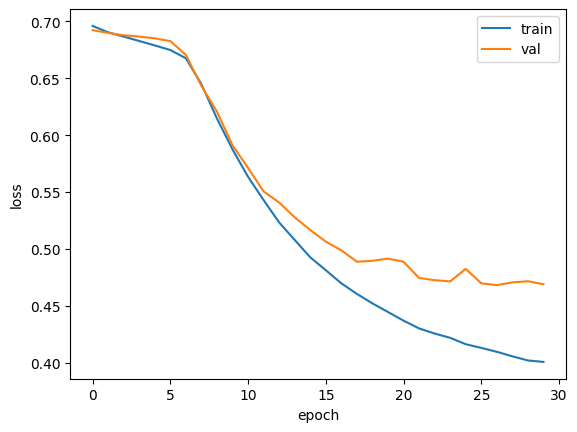

In [54]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# **LSTM 신경망 훈련하기**

In [55]:
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [56]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences (val_input, maxlen=100)

In [59]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.Embedding(500, 16, input_shape=(100,)))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [60]:
model.summary()
# SimpleRNN 클래스의 모델 파라미터 개수는 200개
# LSTM 셀에는 작은 셀이 4개 있으므로 정확히 4배가 늘어 모델 파라미터 개수는 800개가 됨

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model.fit(train_seq, train_target, epochs=100, batch_size=64,
                    validation_data=(val_seq, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5248 - loss: 0.6928

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5250 - loss: 0.6928 - val_accuracy: 0.5774 - val_loss: 0.6920
Epoch 2/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5789 - loss: 0.6916

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5790 - loss: 0.6916 - val_accuracy: 0.6200 - val_loss: 0.6899
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6243 - loss: 0.6889

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6243 - loss: 0.6889 - val_accuracy: 0.6490 - val_loss: 0.6840
Epoch 4/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6597 - loss: 0.6790

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.6597 - loss: 0.6790 - val_accuracy: 0.6940 - val_loss: 0.6412
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6918 - loss: 0.6320

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8128 - loss: 0.4154 - val_accuracy: 0.7982 - val_loss: 0.4362
Epoch 27/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8131 - loss: 0.4140

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8131 - loss: 0.4140 - val_accuracy: 0.8044 - val_loss: 0.4314
Epoch 28/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8155 - loss: 0.4093

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8155 - loss: 0.4093 - val_accuracy: 0.8010 - val_loss: 0.4356
Epoch 29/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8145 - loss: 0.4121

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8144 - loss: 0.4121 - val_accuracy: 0.8056 - val_loss: 0.4319
Epoch 30/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8121 - loss: 0.4135

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8121 - loss: 0.4134 - val_accuracy: 0.7988 - val_loss: 0.4322


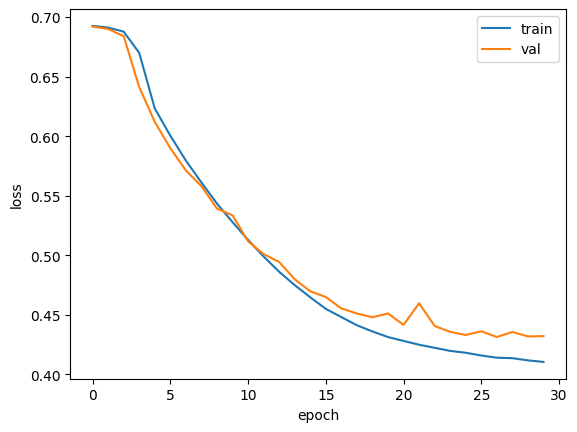

In [62]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# **순환층에 드롭아웃 적용하기**

In [63]:
model2 = keras.Sequential()
model2.add(keras.layers.Embedding(500, 16, input_length=100))
model2.add(keras.layers.LSTM(8, dropout=0.3))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

In [64]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model2.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4984 - loss: 0.6934

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4985 - loss: 0.6934 - val_accuracy: 0.5394 - val_loss: 0.6923
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5635 - loss: 0.6916

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5636 - loss: 0.6916 - val_accuracy: 0.6114 - val_loss: 0.6895
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6117 - loss: 0.6877

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6117 - loss: 0.6877 - val_accuracy: 0.6572 - val_loss: 0.6806
Epoch 4/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6617 - loss: 0.6736

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.6619 - loss: 0.6735 - val_accuracy: 0.7142 - val_loss: 0.6234
Epoch 5/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7104 - loss: 0.6026

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8181 - loss: 0.4084 - val_accuracy: 0.7992 - val_loss: 0.4365
Epoch 38/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8160 - loss: 0.4071

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8160 - loss: 0.4071 - val_accuracy: 0.8042 - val_loss: 0.4256
Epoch 39/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8158 - loss: 0.4064

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8158 - loss: 0.4064 - val_accuracy: 0.8044 - val_loss: 0.4265
Epoch 40/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8149 - loss: 0.4068

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8149 - loss: 0.4068 - val_accuracy: 0.7982 - val_loss: 0.4300
Epoch 41/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8189 - loss: 0.4052

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8188 - loss: 0.4052 - val_accuracy: 0.8062 - val_loss: 0.4265


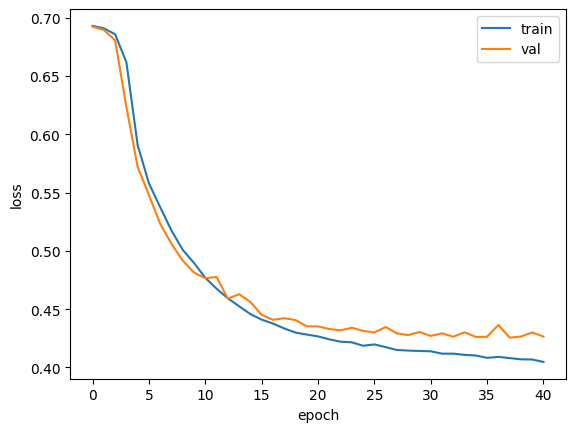

In [65]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# **2개의 층을 연결하기**

In [68]:
model3 = keras.Sequential()
model3.add(keras.layers.Embedding(500, 16, input_shape=(100,)))
model3.add(keras.layers.LSTM(8, dropout=0.3, return_sequences=True))
model3.add(keras.layers.LSTM(8, dropout=0.3))
model3.add(keras.layers.Dense(1, activation='sigmoid'))

In [69]:
model3.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model3.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2rnn-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model3.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5067 - loss: 0.6931

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5067 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5260 - loss: 0.6928

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.5260 - loss: 0.6928 - val_accuracy: 0.5130 - val_loss: 0.6927
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5478 - loss: 0.6924

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.5478 - loss: 0.6924 - val_accuracy: 0.5890 - val_loss: 0.6917
Epoch 4/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5669 - loss: 0.6911

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.5670 - loss: 0.6911 - val_accuracy: 0.6214 - val_loss: 0.6887
Epoch 5/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5766 - loss: 0.6875

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8148 - loss: 0.4182 - val_accuracy: 0.7982 - val_loss: 0.4380
Epoch 36/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8095 - loss: 0.4274

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8095 - loss: 0.4274 - val_accuracy: 0.7964 - val_loss: 0.4343
Epoch 37/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8111 - loss: 0.4236

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8111 - loss: 0.4236 - val_accuracy: 0.7946 - val_loss: 0.4368
Epoch 38/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8082 - loss: 0.4220

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8082 - loss: 0.4221 - val_accuracy: 0.7906 - val_loss: 0.4409
Epoch 39/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8097 - loss: 0.4243

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8097 - loss: 0.4243 - val_accuracy: 0.7954 - val_loss: 0.4425


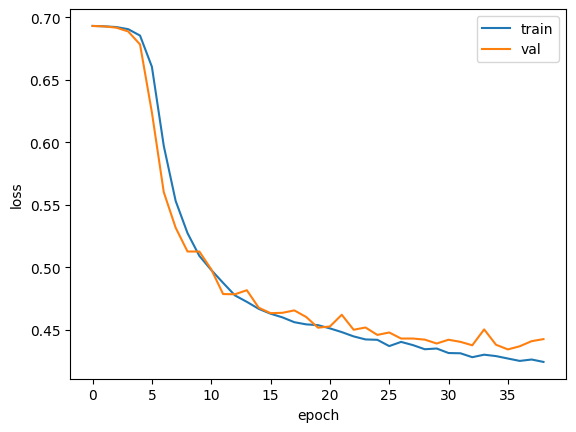

In [71]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# **GRU 구조**

In [72]:
model4 = keras.Sequential()
model4.add(keras.layers.Embedding(500, 16, input_shape=(100,)))
model4.add(keras.layers.GRU(8))
model4.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
model4.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

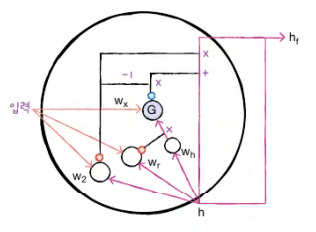

달라진 부분:
- G로 표시된 작은 셀에 들어가는 입력 부분

- 이전에는 가운데 셀의 출력과 은닉 상태가 곱해진 후 G 셀에 입력되었지만 바뀐 그림에서는 은닉 상태가 먼저 가중치와 곱
해진 다음 가운데 셀의 출력과 곱해짐

- 이렇게 나누어 계산하면 은닉 상태에 곱해지는 절편이 별도로 필요함
> 따라서 작은 셀마다 하나씩 절편이 추가되고 8개의 뉴런이 있으므로 총 24개의 모델 파라미터가 더해짐

- 따라서 GRU층의 총 모델 파라미터 개수는 624개가 됨

In [74]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model4.compile(optimizer=rmsprop, loss='binary_crossentropy',
               metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.h5')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model4.fit(train_seq, train_target, epochs=100, batch_size=64,
                     validation_data=(val_seq, val_target),
                     callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5096 - loss: 0.6929

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5096 - loss: 0.6929 - val_accuracy: 0.5316 - val_loss: 0.6920
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5481 - loss: 0.6915

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.5481 - loss: 0.6915 - val_accuracy: 0.5582 - val_loss: 0.6903
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5753 - loss: 0.6896

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.5753 - loss: 0.6896 - val_accuracy: 0.5704 - val_loss: 0.6876
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6024 - loss: 0.6859

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6024 - loss: 0.6859 - val_accuracy: 0.5990 - val_loss: 0.6826
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6189 - loss: 0.6800

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8109 - loss: 0.4286 - val_accuracy: 0.7902 - val_loss: 0.4498
Epoch 22/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8140 - loss: 0.4226

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8140 - loss: 0.4226 - val_accuracy: 0.7924 - val_loss: 0.4481
Epoch 23/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8072 - loss: 0.4289

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8072 - loss: 0.4289 - val_accuracy: 0.7900 - val_loss: 0.4486
Epoch 24/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8132 - loss: 0.4207

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8132 - loss: 0.4207 - val_accuracy: 0.7958 - val_loss: 0.4503
Epoch 25/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8132 - loss: 0.4181

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8132 - loss: 0.4181 - val_accuracy: 0.7864 - val_loss: 0.4557


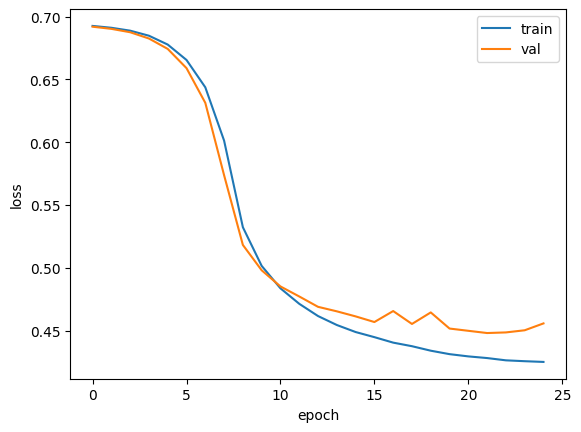

In [75]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [76]:
test_seq = pad_sequences(test_input, maxlen=100)
rnn_model = keras.models.load_model('best-2rnn-model.h5')
rnn_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7965 - loss: 0.4341


[0.435707151889801, 0.7958800196647644]